In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Show plots inline in Jupyter
%matplotlib inline

# Load datasets (adjust the paths if needed)
past = pd.read_csv("newPastCBB.csv")
curr = pd.read_csv("cbb25.csv")

past.head()


,Unnamed: 0,Team,Conf,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,...,3P%D,3PR,3PRD,ADJ_T,WAB,Win%,Year,TeamText,matched_official_team,LostTo
0,0,2011_Ohio_St_,B10,37,34,126.010,91.811,0.97421,56.3200,48.3126,...,34.0147,32.7171,34.6231,63.8246,11.710,0.918919,2011,Ohio St,Ohio St,2011_Kentucky
1,1,2011_Kansas,B12,38,35,120.940,91.060,0.96332,57.0100,44.5110,...,29.8900,32.4179,34.6231,68.0480,10.220,0.921053,2011,Kansas,Kansas,2011_VCU
2,2,2011_Duke,ACC,37,32,120.650,91.580,0.96003,53.7170,44.5110,...,32.4580,35.3113,24.5500,68.5380,9.330,0.864865,2011,Duke,Duke,2011_Arizona
3,3,2011_Texas,B12,36,28,115.521,90.020,0.94604,50.2108,42.5300,...,29.5600,25.5324,26.1120,65.5157,5.413,0.777778,2011,Texas,Texas,2011_Arizona
4,4,2011_Kentucky,SEC,38,29,119.370,93.422,0.94375,52.3410,44.2900,...,32.4580,32.4179,29.7720,64.8191,5.215,0.763158,2011,Kentucky,Kentucky,2011_Connecticut


In [3]:
feature_cols = [
    "G", "W", "ADJOE", "ADJDE", "BARTHAG", "EFG_O", "EFG_D", "TOR", "Seed",
    "TORD", "ORB", "DRB", "FTR", "FTRD", "2P%", "2P%D", "3P%", "3P%D",
    "3PR", "3PRD", "ADJ_T", "WAB",
]

X = past[feature_cols].copy()
y_raw = past["Result"].astype(int)

class_values = np.sort(y_raw.unique())
class_to_index = {v: i for i, v in enumerate(class_values)}
index_to_class = {i: v for v, i in class_to_index.items()}

y = y_raw.map(class_to_index)

print("Classes (tournament finishing positions):", class_values)


Classes (tournament finishing positions): [ 1  2  4  8 16 32 64]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(class_values),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", (y_pred == y_test).mean())
print()
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(c) for c in class_values],
        zero_division=0,  # or 1 if you prefer
    )
)


Accuracy: 0.6222222222222222

              precision    recall  f1-score   support

           1       0.75      0.75      0.75         4
           2       0.00      0.00      0.00         4
           4       0.30      0.38      0.33         8
           8       0.50      0.31      0.38        16
          16       0.43      0.28      0.34        32
          32       0.42      0.39      0.40        64
          64       0.75      0.87      0.80       142

    accuracy                           0.62       270
   macro avg       0.45      0.43      0.43       270
weighted avg       0.59      0.62      0.60       270



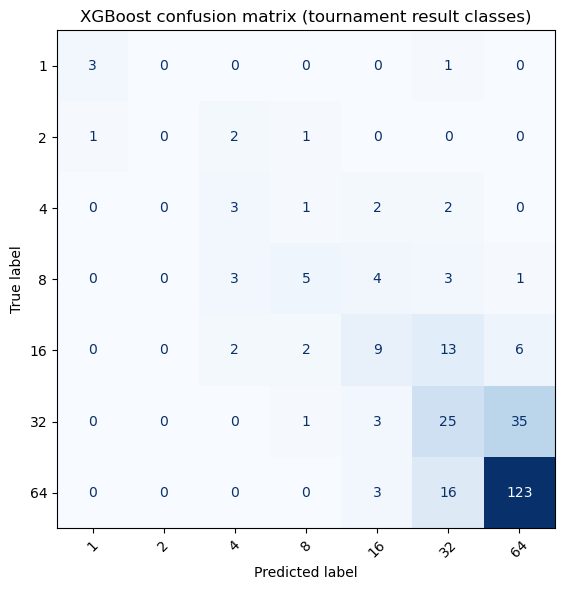

In [6]:
# Confusion matrix for tournament result classes
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_values)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("XGBoost confusion matrix (tournament result classes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

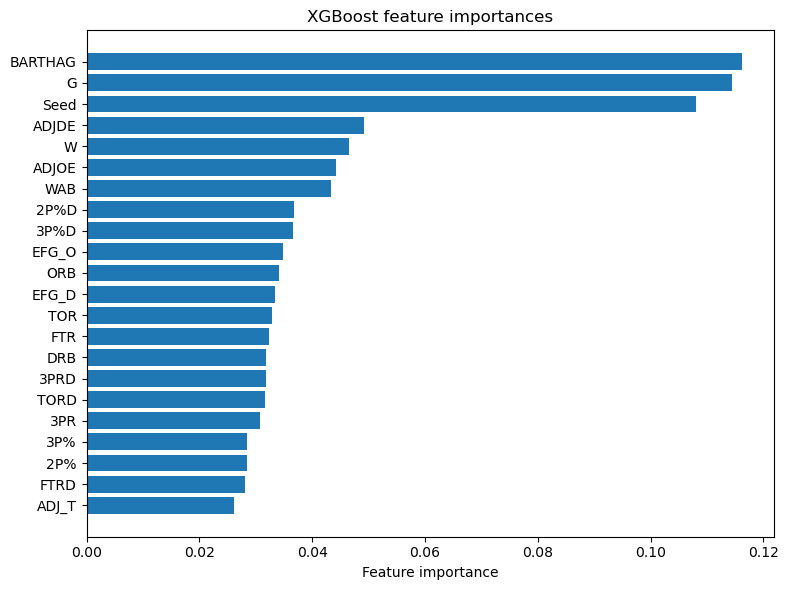

In [7]:
# Feature importances
importances = xgb_model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx])
ax.set_xlabel("Feature importance")
ax.set_title("XGBoost feature importances")
plt.tight_layout()
plt.show()

In [8]:
# Current season teams (from cbb25.csv)
current_teams = curr.copy()

def find_team_row(name, df=current_teams):
    """Return the row in df whose 'Team' contains `name` (case-insensitive)."""
    mask = df["Team"].str.contains(name, case=False, na=False)
    matches = df[mask]
    if len(matches) == 0:
        raise ValueError(f"No team found matching '{name}'.")
    if len(matches) > 1:
        print(f"Warning: multiple teams match '{name}'. Using the first one:")
        print(matches["Team"].tolist())
    return matches.iloc[0]


In [9]:
def predict_game(team1, team2, model=xgb_model, df=current_teams,
                 feature_cols=feature_cols, index_to_class=index_to_class):
    """
    Predict the winner between two teams based on their XGBoost-predicted
    tournament strength.

    Parameters
    ----------
    team1, team2 : str
        Substrings or full names of the teams as listed in the cbb25.csv 'Team' column.

    Returns
    -------
    winner_name : str
        The team name predicted to win.
    """
    # Look up the two teams in the current-season data
    row1 = find_team_row(team1, df)
    row2 = find_team_row(team2, df)

    # Build a small feature matrix for the two teams
    X_pair = pd.DataFrame(
        [row1[feature_cols].values, row2[feature_cols].values],
        columns=feature_cols,
        index=[row1["Team"], row2["Team"]],
    )

    # Predict the tournament result class index for each team
    preds = model.predict(X_pair)

    # Convert class index -> original Result value
    results_numeric = np.array([index_to_class[int(p)] for p in preds])

    # Smaller Result value = deeper tournament run (1 = champion, 64 = lost in R64)
    winner_idx = results_numeric.argmin()
    loser_idx = 1 - winner_idx

    winner_name = X_pair.index[winner_idx]
    loser_name = X_pair.index[loser_idx]

    print("Predicted tournament finish (smaller is better):")
    for name, r in zip(X_pair.index, results_numeric):
        print(f"  {name}: {r}")

    print()
    print(f"Predicted winner: {winner_name} over {loser_name}")
    return winner_name


In [13]:
predict_game("Auburn", "Florida")


Predicted tournament finish (smaller is better):
  Auburn: 32
  Florida: 32

Predicted winner: Auburn over Florida


'Auburn'